In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from modules import dataviz
import joblib
import statsmodels

import modules as mymd

%load_ext autoreload
%autoreload 2

In [369]:
# Téléchargement des dataframes depuis la base de données des BAAC.
urls_y = {
    2022: {
        "carac" : "https://www.data.gouv.fr/api/1/datasets/r/5fc299c0-4598-4c29-b74c-6a67b0cc27e7",
        "lieux" : "https://www.data.gouv.fr/api/1/datasets/r/a6ef711a-1f03-44cb-921a-0ce8ec975995",
        "usagers" : "https://www.data.gouv.fr/api/1/datasets/r/62c20524-d442-46f5-bfd8-982c59763ec8"
    },
    2023 : {
        "carac" : "https://www.data.gouv.fr/api/1/datasets/r/104dbb32-704f-4e99-a71e-43563cb604f2",
        "lieux" : "https://www.data.gouv.fr/api/1/datasets/r/8bef19bf-a5e4-46b3-b5f9-a145da4686bc",
        "usagers" : "https://www.data.gouv.fr/api/1/datasets/r/68848e2a-28dd-4efc-9d5f-d512f7dbe66f"
    },
    2024 : {
        "carac" : "https://www.data.gouv.fr/api/1/datasets/r/83f0fb0e-e0ef-47fe-93dd-9aaee851674a",
        "lieux" : "https://www.data.gouv.fr/api/1/datasets/r/228b3cda-fdfb-4677-bd54-ab2107028d2d",
        "usagers" : "https://www.data.gouv.fr/api/1/datasets/r/f57b1f58-386d-4048-8f78-2ebe435df868"
    }
}

# Dictionnaire qui contiendra les dataframes pour chaque année en vue de la concaténation

dfs = {}

yrl = [2022,2023,2024]
names = ["carac","lieux","usagers"]

for name in names:
    list_df = []
    for yr in yrl:
        url = urls_y[yr][name]
        df_yr = pd.read_csv(url,sep=";") # Le séparateur utilisé est ";"
        df_yr.insert(1,"year",yr) # Colonne année pour distinguer les accidents entre années en vue des opérations de fusion de dataframes
        list_df.append(df_yr)

    concatenated_df_type = pd.concat(list_df,ignore_index=True) # On fait fi de l'index
    dfs[name] = concatenated_df_type # On associe le dataframe des trois années au type de dataframe

dfs

# Prend environ 40 secondes à tourner

KeyboardInterrupt: 

Observons la longueur de chacun des dataframes :

In [ ]:
for n,content in dfs.items(): 
    print(n,len(content))

carac 164526
lieux 196410
usagers 377638


In [ ]:
for name in names:
    dfs[name].to_csv(f"data_interm/new/{name}_new.csv",index=False)

### Charger .csv

In [492]:
names = ["carac","lieux","usagers"]

lieux_new = pd.read_csv("data_interm/new/lieux_new.csv")
usagers_new = pd.read_csv("data_interm/new/usagers_new.csv")
carac_new = pd.read_csv("data_interm//new/carac_new.csv")

Il est normal que le dataframe "usagers" soit le plus long : en effet, pour chaque accident corporel, on peut compter plusieurs victimes. Il est plus surprenant que "lieux" soit plus long que "carac". 
Observons les doublons :

In [493]:
lieux_new["Num_Acc"].value_counts().head(20)

Num_Acc
202300035508    5
202400050330    5
202300039940    4
202300053680    4
202300036543    4
202300007795    4
202300034748    4
202400005122    4
202300046485    4
202300006227    4
202300011843    4
202300054010    4
202300015235    4
202300016172    4
202400005927    4
202400012290    4
202400012979    4
202400013470    4
202400017817    4
202400017969    4
Name: count, dtype: int64

In [494]:
lieux_new[lieux_new["Num_Acc"]==202300035508]

,Num_Acc,year,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma
101231,202300035508,2023,4,BOULEVARD DE BEAUSEJOUR,0,NaN,1,0,0,1,0,0,1,NaN,-1,1,0,1,30
101232,202300035508,2023,4,BOULEVARD EMILE AUGIER,0,NaN,3,2,0,1,-1,-1,1,NaN,-1,1,9,1,50
101233,202300035508,2023,4,CHAUSSEE LA MUETTE,0,NaN,3,1,3,1,-1,-1,1,NaN,-1,1,6,1,50
101234,202300035508,2023,4,RUE D ANDIGNE,0,NaN,1,1,0,1,0,0,1,NaN,-1,1,0,1,30
101235,202300035508,2023,4,RUE LARGILLIERE,0,NaN,2,2,0,1,0,0,1,NaN,-1,1,0,1,30


In [495]:
sum(carac_new["Num_Acc"].value_counts()>1)

0

In [496]:
if "an" in carac_new.columns:
    carac_new.drop(columns=["an"],inplace=True) # Colonne an redondante avec colonne year

"Lieux" indique les différentes voies liées à l'accident lorsqu'il a eu lieu dans une intersection complexe. Il contient par ailleurs différentes informations sur le lieu de l'accident (type de route **catr**, l'état de la surface **surf**, la vitesse maximale autorisée **vma**).

Les données les plus générales sont les "caractéristiques de l'accident", uniques pour chaque accident. Dans chaque accident, on a des données sur le lieu de l'accident et l'avant-accident qui est différent selon les acteurs impliqués. Enfin, la partie "usagers" comporte des informations sur chacun des usagers impliqués dans l'accident ; c'est le dataset le plus large.

## Formatting Dataframe 2022-2024
### Caractéristiques
Observons le dataset "carac".

In [497]:
carac_new.head(20)
# We should likely delete the adr column. We will keep long and lat since we will merge with meteorogical data later on. We can 
# also delete the "com" (city) and "dep" (department) rows, which should be little informative (unless we take into account that some dpts' routes have 
# much more traffic. But wouldn't it already be captured by "autoroute" and "hour", mostly ?)

# What can be smart is to do target encoding with department. Be careful not to leak data.

,Accident_Id,year,jour,mois,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long,Num_Acc
0,2.022000e+11,2022,19,10,16:15,1,26,26198,2,3,1,3,TEIL(vieille route du),"44,5594200000","4,7257200000",NaN
1,2.022000e+11,2022,20,10,08:34,1,25,25204,2,3,1,3,Miranda,"46,9258100000","6,3462000000",NaN
2,2.022000e+11,2022,20,10,17:15,1,22,22360,2,6,1,2,ROND POINT DE BREZILLET,"48,4931620000","-2,7604390000",NaN
3,2.022000e+11,2022,20,10,18:00,1,16,16102,2,3,8,6,LOHMEYER (RUE),"45,6926520000","-0,3262900000",NaN
4,2.022000e+11,2022,19,10,11:45,1,13,13103,1,1,1,2,ROUTE DE JEAN MOULIN-RN 538,"43,6755790366","5,0927031775",NaN
5,2.022000e+11,2022,6,10,14:00,1,13,13056,2,2,1,3,TURCAN FRANCIS,"43,4127500000","5,0505900000",NaN
6,2.022000e+11,2022,20,10,21:00,5,13,13063,2,1,1,1,CARNOT RUE,"43,5822900000","5,0034300000",NaN
7,2.022000e+11,2022,15,10,21:00,5,12,12145,2,2,1,3,JAURES JEAN (AVENUE),"44,1036000000","3,0798400000",NaN
8,2.022000e+11,2022,20,10,09:43,1,10,10387,2,1,8,6,LOMBARDS (AVENUE),"48,2717969874","4,0788030624",NaN
9,2.022000e+11,2022,19,10,12:30,1,10,10387,2,9,1,-1,PREMIER MAI (RUE DU),"48,3041200000","4,0883300000",NaN


On a une importante granularité pour le moment précis de l'accident. Observons s'il y'a des données manquantes.

In [498]:
carac_new=carac_new.replace([-1,"-1"],np.nan)

In [499]:
missing_counts=carac_new.isna().sum()
missing_counts[missing_counts>0]

Accident_Id    109224
lum                 4
int                13
atm                 5
col                82
adr              4932
Num_Acc         55302
dtype: int64

Le volume de données manquantes pour lum, int, atm et col est négligeable. On peut donc imputer par le mode pour ne pas biaiser le modèle.

Nous avons deux colonnes "Num_Acc" et "Accident_Id" qui représentent la même chose ; la colonne a changé de nom avec les années. Vérifions qu'il n'y a pas de contradiction entre les deux colonnes, et qu'elles ne sont jamais toutes deux vides.

In [500]:
both_empty = carac_new[carac_new['Num_Acc'].isna() & carac_new['Accident_Id'].isna()]
both_present = carac_new[carac_new['Num_Acc'].notna() & carac_new['Accident_Id'].notna()]
print(len(both_empty))
print(len(both_present))

0
0


On voit que Accident_Id et Num_Acc se complètent parfaitement. On peut donc fusionner Accident_Id et Num_Acc.

Comme on dispose déjà d'informations sur la configuration de la route et qu'on dispose de toutes les longitudes et latitudes, on peut supprimer la colonne "adresse", qui n'apporte rien de plus.


In [ ]:
import modules.process_carac
carac_new = mymd.clean_carac.clean_carac(carac_new)

In [502]:
missing_counts=carac_new.isna().sum()
missing_counts[missing_counts>0]

Series([], dtype: int64)

### Usagers

Le jeu de données usagers est primordial, car il contient notre variable d'intérêt.

>Pour rappel, **grav** peut prendre quatre valeurs : 
>* -1 = NA
>* 1 = Indemne
>* 2 = Tué
>* 3 = Blessé hospitalisé
>* 4 = Blessé léger

<Axes: xlabel='grav', ylabel='Count'>

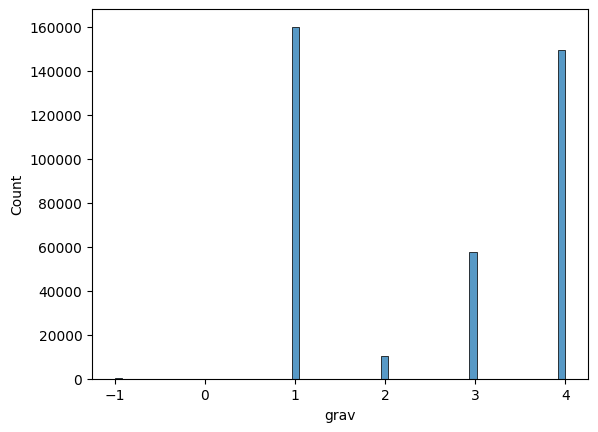

In [503]:
sns.histplot(usagers_new["grav"])

In [504]:
print(round(len(usagers_new[usagers_new["grav"]==-1])/len(usagers_new),5)*100)

# 0.01% des données sont -1 (pas de renseignement) pour la gravité

0.095


Seules 0.095% des enregistrements ont des données manquantes sur la target variable "grav". Elles sont extrêmement minoritaires, nous pouvons donc les supprimer.

In [505]:
usagers_new = usagers_new[usagers_new["grav"]!=-1]

On choisit un mapping ordinal plus cohérent de la gravité de l'accident corporel :

<Axes: xlabel='grav_ord', ylabel='Count'>

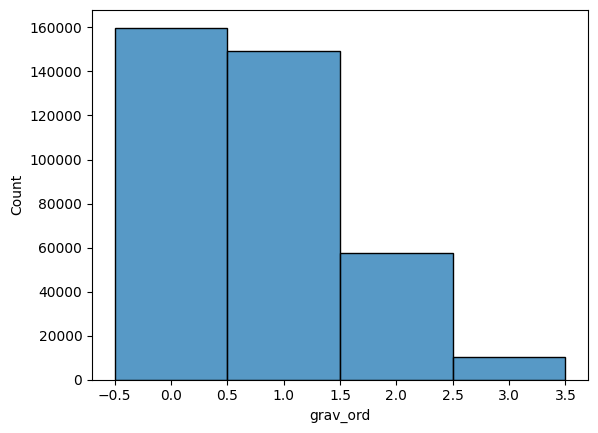

In [506]:
mapping = {1:0, # Indemne
           2:3, # Tué
           3:2, # Blessé hospitalisé
           4:1, # Blessé léger
            }
usagers_new["grav_ord"] = usagers_new["grav"].map(mapping)
usagers_new = usagers_new.drop(columns=["grav"],errors='ignore')
sns.histplot(usagers_new["grav_ord"],discrete=True)

#### Valeurs manquantes

On nettoie les valeurs manquantes de usagers_new à partir du fichier source process_usagers.

In [507]:
df_obj = usagers_new.select_dtypes(['object'])
usagers_new[df_obj.columns] = df_obj.apply(lambda x: x.str.strip())
usagers_new.replace([-1,"-1"], np.nan, inplace=True)

In [508]:
missing_counts=usagers_new.isna().sum()
missing_counts[missing_counts>0]

place           8
sexe         7214
an_nais      7693
trajet       7645
secu1        6751
secu2      167480
secu3      361468
locp       175856
actp       174246
etatp      347453
dtype: int64

In [512]:
usagers_new.select_dtypes(["object"])

,id_usager,id_vehicule,num_veh,actp
0,1 099 700,813 952,A01,NaN
1,1 099 701,813 953,B01,NaN
2,1 099 698,813 950,B01,0
3,1 099 699,813 951,A01,0
4,1 099 696,813 948,A01,NaN
...,...,...,...,...
377633,203 859 570,155 686 119,Y01,NaN
377634,203 859 572,155 686 120,A01,NaN
377635,203 859 569,155 686 118,A01,NaN
377636,203 859 571,155 686 121,B01,NaN


In [514]:
import modules.process_usagers
usagers_new=mymd.process_usagers.clean_usagers(usagers_new)

### Lieux
Observons le dataset "lieux".

In [515]:
lieux_new[lieux_new["Num_Acc"].duplicated(keep=False)].sort_values(by="Num_Acc").head(20)
#Keep=False conserve les duplicates, contrairement au défaut keep=First qui ne montre que la première ligne.

,Num_Acc,year,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma
55302,202300000001,2023,4,RUE DE RIVOLI,0,NaN,1,2,0,1,-1,-1,1,NaN,-1,2,0,1,30
55303,202300000001,2023,4,RUE SAINT FLORENTIN,0,NaN,1,1,0,1,-1,-1,1,NaN,-1,2,0,1,30
55305,202300000003,2023,3,5,0,NaN,2,4,0,1,1,0,1,NaN,-1,2,5,1,50
55306,202300000003,2023,3,87,0,NaN,2,4,0,1,1,0,1,NaN,-1,2,5,1,50
55308,202300000005,2023,4,NaN,0,NaN,1,1,0,1,-1,-1,1,NaN,-1,2,0,1,30
55309,202300000005,2023,4,NaN,0,NaN,2,2,0,1,-1,-1,1,NaN,-1,2,0,1,30
55312,202300000008,2023,3,130,0,NaN,3,4,0,1,-1,-1,1,NaN,-1,2,0,1,50
55313,202300000008,2023,3,NaN,0,NaN,2,2,0,1,-1,-1,1,NaN,-1,2,0,1,50
55314,202300000009,2023,3,5,0,NaN,3,4,0,1,-1,-1,1,NaN,-1,2,5,1,50
55315,202300000009,2023,3,87,0,NaN,1,2,0,1,-1,-1,1,NaN,-1,1,5,1,50


Nous supprimons la colonne voie, qui est bruitée, et peu informative. On supprime donc également v1 et v2, qui donnent l'adresse. On supprime de même les colonnes concernant les points de repère (bornes kilométriques : pr1 et pr2). En effet, nous disposons déjà des longitudes et des latitudes pour chaque enregistrement (cf. caractéristiques plus haut).

A contrario, la VMA (vitesse maximale autorisée), la catégorie de route (catr - autoroute, route urbaine...), l'état de la surface (surf - conditions de la route : verglas, pluie, neige), le régime de circulation (circ - bidirectionnel, unidirectionnel,...), le type d'infrastructure (infra - ponts, tunnels ou carrefours), situation de l'accident (situ - où a précisément eu lieu l'accident : sur la chaussée, sur la bande d'arrêt d'urgence,...), sont particulièrement importantes pour notre prédiction.

Les colonnes plan, prof, nbv, , larrout, vosp, donnent des informations précises sur la configuration des lieux de l'accident. En particulier, prof (topographie), plan (courbure de la route), larrout (largeur de la route) sont très intéressantes.

In [516]:
lieux_new=lieux_new.drop(columns=["voie","v1","v2","pr","pr1"],errors="ignore")

In [517]:
lieux_new[lieux_new["Num_Acc"]==202300000001]

,Num_Acc,year,catr,circ,nbv,vosp,prof,plan,lartpc,larrout,surf,infra,situ,vma
55302,202300000001,2023,4,1,2,0,1,1,NaN,-1,2,0,1,30
55303,202300000001,2023,4,1,1,0,1,1,NaN,-1,2,0,1,30


#### Valeurs manquantes

D'après la description des données, toutes les valeurs -1 correspondent à des valeurs manquantes.

In [518]:
df_obj = lieux_new.select_dtypes(['object'])
lieux_new[df_obj.columns] = df_obj.apply(lambda x: x.str.strip())
lieux_new.replace([-1,"-1"], np.nan, inplace=True)

Observons quelles variables sont concernées. Nous traiterons la VMA plus bas.

In [519]:
missing_counts = lieux_new.isna().sum()
print(missing_counts[missing_counts>0],len(lieux_new))

circ        12535
nbv          8892
vosp         7950
prof          268
plan          207
lartpc     196318
larrout    152686
surf          255
infra        2429
situ          243
vma          9105
dtype: int64 196410


Dans  le cas du jeu de données lieux, l'opération est plus délicate, car de nombreuses valeurs sont interdépendantes. Nous utiliserons la catégorie de route, jamais manquante, pour remplacer les valeurs manquantes de nbv, puis de VMA plus bas.
Pour rappel : 

Catégorie de route :
* 1 – Autoroute
* 2 – Route nationale
* 3 – Route Départementale
* 4 – Voie Communales
* 5 – Hors réseau public
* 6 – Parc de stationnement ouvert à la circulation publique
* 7 – Routes de métropole urbaine
* 9 – autre 

Nous supprimons la colonne lartpc, qui n'est présente que pour 92 enregistrements sur 196410.

On remplace les valeurs manquantes de nbv (nombre de voies), au nombre de 233 sur plus de 196000, par la médiane de la catégorie de route concernée.

On impute par le mode (valeur majoritaire) pour 'circ' (régime de circulation), 'vosp' (voie réservée), 'prof' (profil), 'plan' (courbure), 'infra' (infrastructure) et 'situ' (situation de l'accident).

Pour les données sur l'état de la surface de la route, nous utilisons la colonne "atm" (circonstances atmosphériques) du jeu de données carac.


In [520]:
lieux_new = lieux_new.merge(carac_new[["Num_Acc","atm"]],on="Num_Acc",how="left")

In [521]:
import modules.process_lieux
lieux_new=mymd.process_lieux.clean_lieux(lieux_new)
lieux_new.drop(columns="atm",inplace=True,errors="ignore")

c:\Users\berna\Documents\GitHub\projet_python_ENSAE\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\berna\Documents\GitHub\projet_python_ENSAE\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\berna\Documents\GitHub\projet_python_ENSAE\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\berna\Documents\GitHub\projet_python_ENSAE\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\berna\Documents\GitHub\projet_python_ENSAE\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a,

In [522]:
lieux_new["Num_Acc"].isin(usagers_new["Num_Acc"]).all()
# On a bien une correspondance parfaite entre les lignes de "carac" et les lignes de "usagers". 

np.True_

In [523]:
carac_new["Num_Acc"].isin(lieux_new["Num_Acc"]).all()
# On a également une correspondance entre les lignes de "carac" et les lignes de "lieux". On peut donc bien fusionner en faisant correspondre 
# toutes les lignes avec chaque dataset

np.True_

### Premier merge

Nous souhaitons fusionner les données de 2022, 2023, et 2024, pour les dataframes usagers, carac, et lieux. 
Un problème est que nous avons plusieurs lignes par accident pour "lieux" et pour "usagers" : une ligne par victime dans "usagers", plusieurs lignes possibles dans "lieux" si l'accident s'est produit à une intersection. 

Comme nous observons ci-dessous, le dataframe "carac" dispose bien d'une seule ligne par accident.

In [524]:
(carac_new["Num_Acc"].value_counts()!=1).sum()

np.int64(0)

Si nous conservons toutes les lignes de "lieux", nous devrons dupliquer les lignes des victimes, ce qui faussera nos statistiques de sécurité routière (nombre de victimes gonflé). 

Nous devons donc aplatir les lignes du dataset "lieux".

In [525]:
for count in range(1,3):
    print(
    f"{round((lieux_new["Num_Acc"].value_counts()>count).sum()/len(lieux_new),3)*100}% des accidents \
ont strictement plus de {count} ligne(s) pour 'lieux'.")

16.0% des accidents ont strictement plus de 1 ligne(s) pour 'lieux'.
0.2% des accidents ont strictement plus de 2 ligne(s) pour 'lieux'.


In [526]:
print(lieux_new.duplicated().sum())

5326


Dans 16% des cas, nous avons deux routes pour l'accident (on est face à une intersection). Pour conserver l'information, nous créons une nouvelle variable "nb_routes" et nous sélectionnons la route principale (Autoroute>Nationale>Départementale>...) pour caractériser le lieu de l'accident. Comme les cas où on a plus de trois routes impliquées correspond à 0.2% des cas, nous pouvons supprimer ces enregistrements.

Nous faisons l'hypothèse que la gravité de l'accident sera principalement dictée par la route où la limite de vitesse est la plus élevée, où le le nombre de voies est le plus élevé, et où la largeur précise de chaque voie est la plus élevée.

On supprime d'abord les doublons parfaits.

In [527]:
lieux_new=lieux_new.drop_duplicates()
lieux_new

,Num_Acc,year,catr,circ,nbv,vosp,prof,plan,larrout,surf,infra,situ,vma
0,202200000001,2022,4,2.0,2.0,0.0,1.0,1.0,4.0,1.0,0.0,1.0,50.0
1,202200000002,2022,4,2.0,2.0,0.0,1.0,1.0,4.0,1.0,0.0,1.0,50.0
2,202200000003,2022,3,2.0,2.0,0.0,1.0,1.0,6.0,1.0,5.0,1.0,50.0
3,202200000004,2022,4,1.0,1.0,0.0,2.0,1.0,4.0,1.0,0.0,1.0,30.0
4,202200000005,2022,3,2.0,2.0,0.0,1.0,1.0,6.0,1.0,0.0,1.0,80.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
196405,202400054398,2024,3,1.0,1.0,0.0,1.0,1.0,3.0,2.0,5.0,4.0,NaN
196406,202400054399,2024,3,1.0,1.0,2.0,1.0,2.0,3.0,1.0,0.0,1.0,30.0
196407,202400054400,2024,2,1.0,2.0,0.0,2.0,1.0,10.0,1.0,0.0,1.0,110.0
196408,202400054401,2024,3,2.0,3.0,0.0,1.0,1.0,9.0,1.0,0.0,1.0,50.0


In [528]:
lieux_new[lieux_new.duplicated(subset=["Num_Acc"],keep=False)]
#La feature qui change peut être complètement différente d'un accident à l'autre. 
#Nous devons donc hiérarchiser.

,Num_Acc,year,catr,circ,nbv,vosp,prof,plan,larrout,surf,infra,situ,vma
55302,202300000001,2023,4,1.0,2.0,0.0,1.0,1.0,4.0,2.0,0.0,1.0,30.0
55303,202300000001,2023,4,1.0,1.0,0.0,1.0,1.0,3.0,2.0,0.0,1.0,30.0
55308,202300000005,2023,4,1.0,1.0,0.0,1.0,1.0,3.0,2.0,0.0,1.0,30.0
55309,202300000005,2023,4,2.0,2.0,0.0,1.0,1.0,4.0,2.0,0.0,1.0,30.0
55312,202300000008,2023,3,3.0,4.0,0.0,1.0,1.0,12.0,2.0,0.0,1.0,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
196393,202400054388,2024,4,2.0,2.0,0.0,1.0,1.0,4.0,1.0,0.0,1.0,30.0
196398,202400054393,2024,3,2.0,4.0,2.0,1.0,1.0,12.0,1.0,9.0,1.0,50.0
196399,202400054393,2024,3,1.0,1.0,1.0,1.0,1.0,3.0,1.0,0.0,8.0,30.0
196404,202400054398,2024,3,2.0,3.0,0.0,1.0,1.0,9.0,2.0,5.0,4.0,50.0


In [529]:
# Creation d'une feature binaire comptant le nombre de paramètres de lieux dans l'accident (1 ou 2)

lieux_new["nb_param_lieux"]=lieux_new.groupby(["year","Num_Acc"])["Num_Acc"].transform("size")
lieux_new

,Num_Acc,year,catr,circ,nbv,vosp,prof,plan,larrout,surf,infra,situ,vma,nb_param_lieux
0,202200000001,2022,4,2.0,2.0,0.0,1.0,1.0,4.0,1.0,0.0,1.0,50.0,1
1,202200000002,2022,4,2.0,2.0,0.0,1.0,1.0,4.0,1.0,0.0,1.0,50.0,1
2,202200000003,2022,3,2.0,2.0,0.0,1.0,1.0,6.0,1.0,5.0,1.0,50.0,1
3,202200000004,2022,4,1.0,1.0,0.0,2.0,1.0,4.0,1.0,0.0,1.0,30.0,1
4,202200000005,2022,3,2.0,2.0,0.0,1.0,1.0,6.0,1.0,0.0,1.0,80.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196405,202400054398,2024,3,1.0,1.0,0.0,1.0,1.0,3.0,2.0,5.0,4.0,NaN,2
196406,202400054399,2024,3,1.0,1.0,2.0,1.0,2.0,3.0,1.0,0.0,1.0,30.0,1
196407,202400054400,2024,2,1.0,2.0,0.0,2.0,1.0,10.0,1.0,0.0,1.0,110.0,1
196408,202400054401,2024,3,2.0,3.0,0.0,1.0,1.0,9.0,1.0,0.0,1.0,50.0,1


In [530]:
lieux_new = lieux_new.sort_values(
    by=[
        "year", "Num_Acc", 
        "catr",      # Critère 1 : La classe administrative (1=Autoroute gagne)
        "vma",       # Critère 2 (Si catr égal) : La vitesse (80 gagne vs 50)
        "nbv",       # Critère 3 (Si catr et vma égaux) : Le gabarit (2 voies gagne)
        "larrout"    # Critère 4 (Si tout le reste égal) : La largeur précise de la voie (nous gardons la + grande)
    ],
    ascending=[
        True, True, 
        True,        # catr : croissant (1 est mieux)
        False,       # vma : décroissant (plus grand est mieux)
        False,       # nbv : décroissant
        False        # larrout : décroissant
    ]
)
lieux_clean = lieux_new.drop_duplicates(subset=["year", "Num_Acc"], keep="first")

In [531]:
lieux_clean

,Num_Acc,year,catr,circ,nbv,vosp,prof,plan,larrout,surf,infra,situ,vma,nb_param_lieux
0,202200000001,2022,4,2.0,2.0,0.0,1.0,1.0,4.0,1.0,0.0,1.0,50.0,1
1,202200000002,2022,4,2.0,2.0,0.0,1.0,1.0,4.0,1.0,0.0,1.0,50.0,1
2,202200000003,2022,3,2.0,2.0,0.0,1.0,1.0,6.0,1.0,5.0,1.0,50.0,1
3,202200000004,2022,4,1.0,1.0,0.0,2.0,1.0,4.0,1.0,0.0,1.0,30.0,1
4,202200000005,2022,3,2.0,2.0,0.0,1.0,1.0,6.0,1.0,0.0,1.0,80.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196404,202400054398,2024,3,2.0,3.0,0.0,1.0,1.0,9.0,2.0,5.0,4.0,50.0,2
196406,202400054399,2024,3,1.0,1.0,2.0,1.0,2.0,3.0,1.0,0.0,1.0,30.0,1
196407,202400054400,2024,2,1.0,2.0,0.0,2.0,1.0,10.0,1.0,0.0,1.0,110.0,1
196408,202400054401,2024,3,2.0,3.0,0.0,1.0,1.0,9.0,1.0,0.0,1.0,50.0,1


Maintenant que nous avons "aplati" le dataset "lieux", créons un premier dataset général qui fusionne les données de 2022,2023, et 2024 pour les dataframes **usagers**, **carac**, et **lieux** :

In [532]:
carac_new

,Num_Acc,year,jour,mois,hrmn,lum,dep,com,agg,int,atm,col,lat,long
0,2.022000e+11,2022,19,10,16:15,1.0,26,26198,2,3.0,1.0,3.0,"44,5594200000","4,7257200000"
1,2.022000e+11,2022,20,10,08:34,1.0,25,25204,2,3.0,1.0,3.0,"46,9258100000","6,3462000000"
2,2.022000e+11,2022,20,10,17:15,1.0,22,22360,2,6.0,1.0,2.0,"48,4931620000","-2,7604390000"
3,2.022000e+11,2022,20,10,18:00,1.0,16,16102,2,3.0,8.0,6.0,"45,6926520000","-0,3262900000"
4,2.022000e+11,2022,19,10,11:45,1.0,13,13103,1,1.0,1.0,2.0,"43,6755790366","5,0927031775"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164521,2.024001e+11,2024,10,7,02:05,5.0,94,94065,2,3.0,2.0,6.0,"48,75740000","2,34469000"
164522,2.024001e+11,2024,30,11,15:27,1.0,92,92062,2,1.0,1.0,6.0,"48,88694322","2,24863619"
164523,2.024001e+11,2024,24,10,20:40,3.0,29,29068,1,1.0,1.0,1.0,"48,52619024","-3,96317650"
164524,2.024001e+11,2024,30,11,15:40,1.0,92,92012,2,1.0,1.0,3.0,"48,83286197","2,24394009"


In [533]:
KEY = ["year","Num_Acc"]

df_final2224 = usagers_new\
    .merge(lieux_clean,on=KEY,how="left")\
    .merge(carac_new,on=KEY,how="left")

# On garde toutes les lignes usagers


print(df_final2224.shape[0]==usagers_new.shape[0])

# df_final et usagers_new font bien la même longueur.

True


In [534]:
df_final2224.to_parquet("data_interm/df_final2224.parquet",index=False)

### Parquet loading

In [673]:
df_final2224 = pd.read_parquet("data_interm/df_final2224.parquet")

On crée un score de gravité des accidents. Les blessés ont un poids de 1, les indemnes de 0, les morts de 5.

In [685]:
df_final2224["grav_weight"]=df_final2224["grav_ord"].map({3:6,2:3,1:1,0:0})
s_grav_score=df_final2224.groupby("Num_Acc")["grav_weight"].transform("sum").rename("grav_score")
df_final2224["grav_score"]=s_grav_score

In [686]:
s_grav_score.head(20)

0     3
1     3
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    2
13    2
14    2
15    1
16    1
17    1
18    1
19    1
Name: grav_score, dtype: int64

### Cartographie accidents 22-24
Nous pouvons observer la carte des accidents de la route de ce dataframe.

In [687]:
df_map = df_final2224.drop_duplicates(subset=["Num_Acc"])[["lat","long"]].copy()

# Pour utiliser folium, on doit remplacer les virgules par des points dans long et lat

df_map["lat"]=pd.to_numeric(df_map["lat"].apply(lambda x:str(x).replace(',','.')))
df_map["long"]=pd.to_numeric(df_map["long"].apply(lambda x:str(x).replace(',','.')))

df_map.sample(20)

,lat,long
168551,43.447790,-1.573700
99581,48.625520,2.314060
152030,43.040979,2.833958
374420,48.274149,-4.324208
55036,47.281290,-2.242380
203075,48.260259,6.177090
107353,45.533702,5.586113
222000,47.865058,3.502611
284869,48.918044,2.222130
65227,48.705110,6.222360


Pour la visualisation, on ne garde que la France Métropolitaine.

In [688]:
df_map = df_map[
    (41<df_map["lat"])&(df_map["lat"]<52) &
    (-6<df_map["long"])&(df_map["long"]<10)
]
df_map.head(20)

,lat,long
0,44.559420,4.725720
2,46.925810,6.346200
4,48.493162,-2.760439
6,45.692652,-0.326290
8,43.675579,5.092703
10,43.412750,5.050590
12,43.582290,5.003430
15,44.103600,3.079840
17,48.271797,4.078803
19,48.304120,4.088330


In [689]:
df_map[df_map["lat"]>90] 

,lat,long


Les données sont bien en GPS, pas besoin de les convertir (toutes les données sont inférieures à 90)

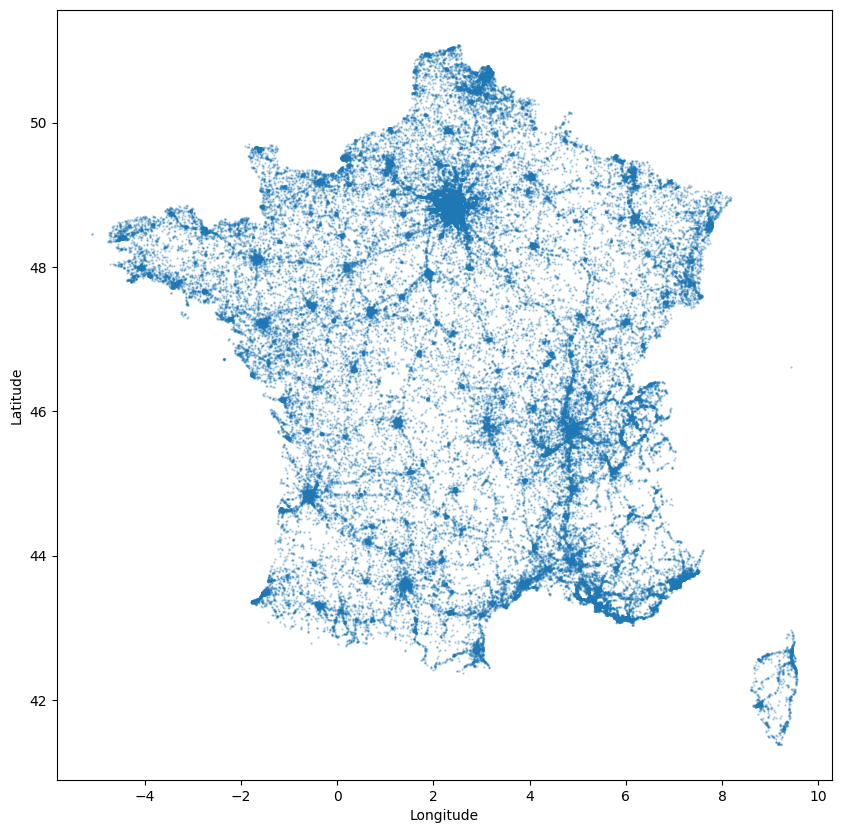

In [690]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.scatter(df_map["long"],df_map["lat"],s=0.5,alpha=0.3)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

On peut clairement distinguer les zones urbaines des zones rurales. Il semble y'avoir une corrélation entre les zones à forte densité de population et le nombre d'accidents. Nous pouvons vérifier ça.

Note :  Si Folium renvoie "Make this notebook trusted to load map...", et si dans VSCode, faire Ctrl+Shift+P (Ouvre la barre de recherche avec >) puis écrire : Jupyter:Trust Notebook, puis appuyer sur Entrée. Ensuite, Restart Kernel et lancer le code. Si cela ne fonctionne pas, écrire Jupyter:Trust Notebook et relancer VSCode.

In [691]:
import geopandas as gpd
import folium 
from folium.plugins import HeatMap

gdf = gpd.GeoDataFrame(
    df_map,
    geometry = gpd.points_from_xy(df_map.long,df_map.lat),
)
print(f"Nous affichons exactement {len(gdf)} points.")

# Carte centrée sur la France
m = folium.Map(location=[46.6,2.2],zoom_start=6,tiles="CartoDB positron") # zoom_start dézoome la carte initiale

# Nous utilisons une carte de chaleur pour mieux voir les zones dangereuses
heat_data = gdf[["lat","long"]].values.tolist()
HeatMap(heat_data,radius=10,blur=10).add_to(m)


m


Nous affichons exactement 155075 points.


Comparons les données sur les accidents aux densités de population.

In [726]:
url_pop = "https://public.opendatasoft.com/api/explore/v2.1/catalog/datasets/correspondance-code-insee-code-postal/exports/csv?lang=fr&timezone=Europe%2FParis&use_labels=true&delimiter=%3B"

df_communes = pd.read_csv(url_pop, sep=';')

In [727]:
df_communes

,Code INSEE,Code Postal,Commune,Département,Région,Statut,Altitude Moyenne,Superficie,Population,geo_point_2d,geo_shape,ID Geofla,Code Commune,Code Canton,Code Arrondissement,Code Département,Code Région
0,33332,33660,PORCHERES,GIRONDE,AQUITAINE,Commune simple,44.0,1336.0,0.9,"45.0370123077, 0.00132456186091","{""coordinates"": [[[0.016455839257392, 45.02657...",131,332,22,5,33,72
1,41281,41330,VILLEFRANCOEUR,LOIR-ET-CHER,CENTRE,Commune simple,121.0,1826.0,0.5,"47.696504262, 1.20343836438","{""coordinates"": [[[1.199842837063046, 47.67086...",29861,281,6,1,41,24
2,19029,19500,BRANCEILLES,CORREZE,LIMOUSIN,Commune simple,171.0,1152.0,0.3,"45.0080597171, 1.708482812","{""coordinates"": [[[1.703376659040107, 44.98657...",34112,29,18,1,19,74
3,73058,73520,LA BRIDOIRE,SAVOIE,RHONE-ALPES,Commune simple,329.0,624.0,1.2,"45.5299612439, 5.73849540904","{""coordinates"": [[[5.750034975896888, 45.51647...",34852,58,21,2,73,82
4,82137,82160,PARISOT,TARN-ET-GARONNE,MIDI-PYRENEES,Commune simple,351.0,2804.0,0.5,"44.2617881809, 1.86571509225","{""coordinates"": [[[1.845927346329462, 44.22938...",24331,137,20,2,82,73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36737,07141,07200,LENTILLERES,ARDECHE,RHONE-ALPES,Commune simple,553.0,878.0,0.2,"44.6092419896, 4.29820132309","{""coordinates"": [[[4.318937225026731, 44.59065...",4061,141,3,1,07,82
36738,07200,07560,LE ROUX,ARDECHE,RHONE-ALPES,Commune simple,1068.0,1659.0,0.0,"44.7211157335, 4.14333586468","{""coordinates"": [[[4.139961341900978, 44.69697...",31114,200,12,1,07,82
36739,76564,76740,SAINT-AUBIN-SUR-MER,SEINE-MARITIME,HAUTE-NORMANDIE,Commune simple,31.0,638.0,0.3,"49.8888204893, 0.875914099002","{""coordinates"": [[[0.912217914104911, 49.89105...",25282,564,22,1,76,23
36740,67232,67250,KEFFENACH,BAS-RHIN,ALSACE,Commune simple,180.0,242.0,0.2,"48.9666217259, 7.88352123291","{""coordinates"": [[[7.895851150980904, 48.95889...",18994,232,26,7,67,42


In [ ]:
df_communes.sort_values(by="Code INSEE",inplace=True)
df_communes

,Code INSEE,Code Postal,Commune,Département,Région,Statut,Altitude Moyenne,Superficie,Population,geo_point_2d,geo_shape,ID Geofla,Code Commune,Code Canton,Code Arrondissement,Code Département,Code Région
11369,01001,01400,L'ABERGEMENT-CLEMENCIAT,AIN,RHONE-ALPES,Commune simple,242.0,1565.0,0.8,"46.1534255214, 4.92611354223","{""coordinates"": [[[4.92627342692396, 46.120051...",7342,1,10,2,01,82
16018,01002,01640,L'ABERGEMENT-DE-VAREY,AIN,RHONE-ALPES,Commune simple,483.0,912.0,0.2,"46.0091878776, 5.42801696363","{""coordinates"": [[[5.430089291292173, 45.98275...",32385,2,1,1,01,82
2301,01004,01500,AMBERIEU-EN-BUGEY,AIN,RHONE-ALPES,Chef-lieu canton,379.0,2448.0,13.4,"45.9608475114, 5.3729257777","{""coordinates"": [[[5.386190824025674, 45.93092...",463,4,1,1,01,82
19912,01005,01330,AMBERIEUX-EN-DOMBES,AIN,RHONE-ALPES,Commune simple,290.0,1605.0,1.6,"45.9961799872, 4.91227250796","{""coordinates"": [[[4.895580369408855, 45.97991...",344,5,30,2,01,82
36546,01006,01300,AMBLEON,AIN,RHONE-ALPES,Commune simple,589.0,602.0,0.1,"45.7494989044, 5.59432017366","{""coordinates"": [[[5.614854625053272, 45.73463...",16853,6,4,1,01,82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11708,97613,97650,M'TSANGAMOUJI,MAYOTTE,MAYOTTE,Chef-lieu canton,96.0,2155.0,5.0,"-12.7513099309, 45.0871696871","{""coordinates"": [[[45.10168867076047, -12.7775...",5,613,15,0,97,6
17479,97614,97670,OUANGANI,MAYOTTE,MAYOTTE,Chef-lieu canton,175.0,1828.0,6.6,"-12.8370955196, 45.1379095497","{""coordinates"": [[[45.15401500566175, -12.8740...",10,614,16,0,97,6
9684,97615,97610,PAMANDZI,MAYOTTE,MAYOTTE,Chef-lieu canton,52.0,426.0,9.1,"-12.7961353309, 45.2842063102","{""coordinates"": [[[45.2964579398932, -12.78406...",11,615,17,0,97,6
14950,97616,97640,SADA,MAYOTTE,MAYOTTE,Chef-lieu canton,130.0,1085.0,8.0,"-12.8611649609, 45.1185503145","{""coordinates"": [[[45.13226166584437, -12.8888...",6,616,18,0,97,6


In [729]:
df_communes["lat_commune"].isna().sum()

KeyError: 'lat_commune'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

print("Chargement des données...")
url_pop = "https://public.opendatasoft.com/api/explore/v2.1/catalog/datasets/correspondance-code-insee-code-postal/exports/csv?lang=fr&timezone=Europe%2FParis&use_labels=true&delimiter=%3B"

df_communes = pd.read_csv(url_pop, sep=';')

# Coordonnées
if 'geo_point_2d' in df_communes.columns:
    df_communes[['lat_commune', 'lon_commune']] = df_communes['geo_point_2d'].str.split(',', expand=True).astype(float)

# Nettoyage
df_communes = df_communes.dropna(subset=['lat_commune', 'lon_commune', 'Population'])
df_communes_plot = df_communes[
    (df_communes['lat_commune'] > 41) & (df_communes['lat_commune'] < 52) &
    (df_communes['lon_commune'] > -5) & (df_communes['lon_commune'] < 10)
]

df_accidents = df_map.copy()
df_accidents['lat'] = pd.to_numeric(df_accidents['lat'].astype(str).str.replace(',', '.'), errors='coerce')
df_accidents['long'] = pd.to_numeric(df_accidents['long'].astype(str).str.replace(',', '.'), errors='coerce')

df_accidents = df_accidents.dropna(subset=['lat', 'long'])


# plt.figure(figsize=(10, 10))

# # Couche 1 : Population

# plt.scatter(
#     df_communes['lon_commune'],
#     df_communes['lat_commune'],
#     s=df_communes['Population'],
#     c='blue',
#     alpha=0.3,       # Transparence modérée
#     linewidth=0,     # Pas de bordure pour garder l'aspect "point"
#     label='Population'
# )

# # Couche 2 : Accidents

# plt.scatter(
#     df_accidents['long'],
#     df_accidents['lat'],
#     s=0.5,           # Taille fixe très fine
#     c='red', 
#     alpha=0.3,       # Transparence pour voir la densité
#     linewidth=0,
#     label='Accidents'
# )

# plt.title("Carte brute : Population (Bleu) vs Accidents (Rouge)")
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.axis('equal')

# # Légende forcée (pour voir les points même s'ils sont petits sur la carte)
# lgnd = plt.legend()
# for handle in lgnd.legend_handles:
#     handle.set_alpha(1) 

# plt.show()

Chargement des données...


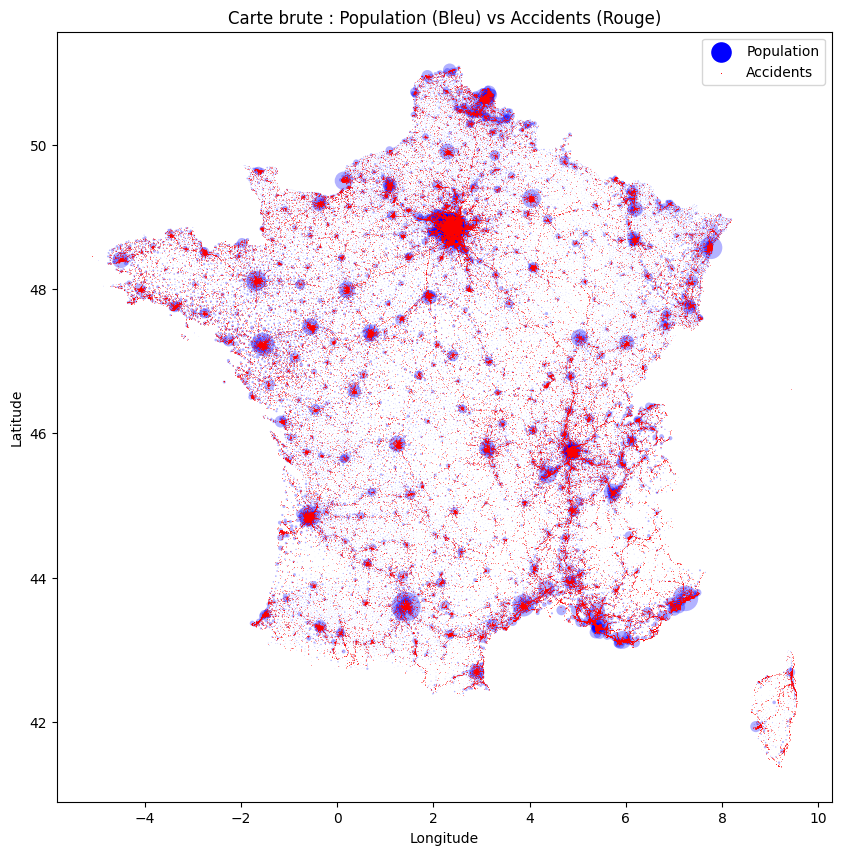

In [693]:
from modules import dataviz as pgf
pgf.plot_pop_nbacc(df_communes_plot,df_accidents)

La corrélation entre la densité de population d'une région et la quantité d'accidents qui y a lieu est très nette. On peut s'y attendre : plus il y'a de personnes, plus il y'a de trafic, et plus il y'a d'accidents. Par contre, nous utiliserons plus tard la densité de population pour observer si justement, elle est négativement corrélée à la gravité d'un accident dans la région ou pas.

Modifions les couleurs pour pouvoir visualiser où ont lieux les accidents les plus graves (la gravité d'un accident au score de gravité défini plus haut)

In [694]:
# On merge sur l'index 
df_accidents_grv=pd.merge(df_accidents,s_grav_score,left_index=True,right_index=True)
df_accidents_grv=df_accidents_grv.sort_values(by="grav_score",ascending=True)
df_accidents_grv.head(20)

,lat,long,grav_score
377266,48.832862,2.243940,1
38,48.851387,2.343186,1
40,48.868641,2.389567,1
42,48.852277,2.280041,1
44,48.864518,2.269805,1
46,48.877203,2.283821,1
48,48.841565,2.292519,1
49,48.837326,2.328577,1
50,48.823317,2.365701,1
53,48.864787,2.410108,1


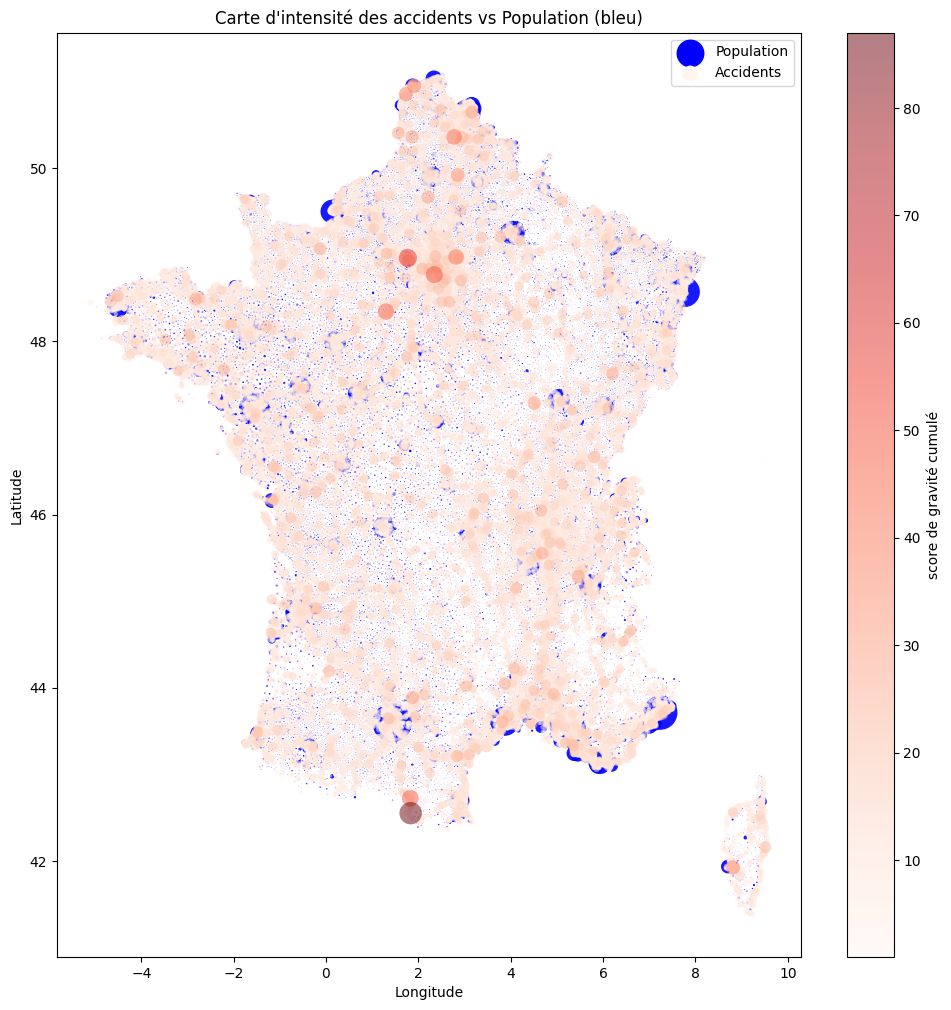

In [695]:
from modules import dataviz as pgf
pgf.plot_grav_score(df_communes_plot,df_accidents_grv,
                    # params={"alpha_acc":0.3,"alpha_pop":0.4}
                    )

# plt.figure(figsize=(12, 12))

# plt.scatter(
#     df_communes['lon_commune'],
#     df_communes['lat_commune'],
#     s=df_communes['Population']*1.5,
#     c='blue',
#     alpha=0.5,       # Transparence modérée
#     linewidth=0,     # Pas de bordure pour garder l'aspect "point"
#     label='Population'
# )

# # Couche 2 : Accidents, colorés selon leur score de gravité 

# sc = plt.scatter(
#     df_accidents_grv['long'],
#     df_accidents_grv['lat'],
#     s=0.5+df_accidents_grv['grav_score']**1.7,           # Taille fixe très fine, qui grossit avec la gravité de l'accident
#     c=df_accidents_grv["grav_score"],
#     cmap="Reds", 
#     alpha=0.6,       # Transparence pour voir la densité
#     linewidth=0,
#     label='Accidents',
#     )

# plt.title("Carte d'intensité des accidents vs Population (bleu)")
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.axis('equal')

# cbar = plt.colorbar(sc) # Barre de couleur pour lire les scores
# cbar.set_label("score de gravité cumulé")

# # Légende forcée (pour voir les points même s'ils sont petits sur la carte)
# lgnd = plt.legend()
# for handle in lgnd.legend_handles:
#     handle.set_alpha(1) 

# plt.show()

### Analyse du score de gravité à l'échelle des communes

On souhaite maintenant observer la gravité moyenne des accidents par commune, et son rapport avec la densité de population.

On filtre les communes avec sans habitants (ou celles pour lesquelles on n'a pas l'information)

In [696]:
df_final2224=df_final2224.rename(columns={"com":"Code INSEE"})

Pour faciliter la lecture, on convertir les unités pour la population et la superficie de chaque commune.

In [697]:
df_communes["Population"]=df_communes["Population"]*1000 # Nombre d'habitants 
df_communes["Superficie"]=df_communes["Superficie"]/100 # Hectares -> Kilomètre carré

Créons un dataframe df_plot_densite qui contient la densité de population, le nombre d'accidents, et la gravité moyenne par commune.

In [698]:
com_gravity = df_final2224.groupby('Code INSEE').agg(score_moyen_com=("grav_weight","mean"),
                                              nb_accidents_com=("Num_Acc","count")
).reset_index()

df_communes["densite"]=df_communes["Population"]/df_communes["Superficie"] # Milliers de personnes par hectare

df_plot_densite = com_gravity.merge(df_communes[["Code INSEE","densite"]],on="Code INSEE")
df_plot_densite=df_plot_densite[(df_plot_densite["densite"]>0)&(df_plot_densite["densite"].notna())]

On observe ci-dessous une corrélation négative entre la densité de population et la gravité des accidents.
Cela peut être lié à plusieurs facteurs : 
- En zone peu dense, les limites de vitesses ont tendance à être plus élevées. Une forte vitesse cause des accidents plus graves.
- En zone peu dense, l'intervention des pompiers et du SAMU est beaucoup plus lente. 

Text(0.5, 0, 'Log(Densité de population habitant/km²)')

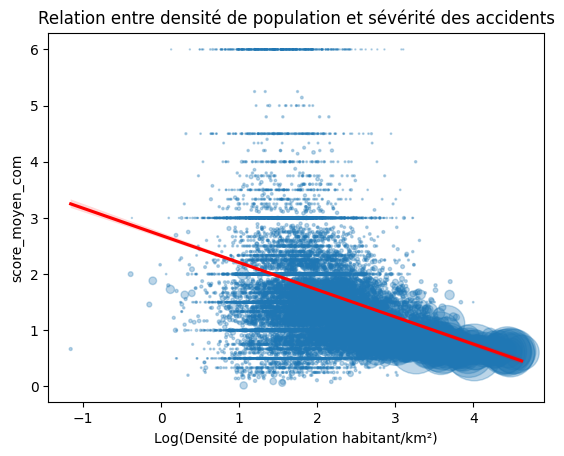

In [699]:
sns.regplot(x=np.log10(df_plot_densite['densite']), y=df_plot_densite['score_moyen_com'], 
            scatter_kws={'alpha':0.3, 's': df_plot_densite['nb_accidents_com']/2},  
            line_kws={'color':'red'})

plt.title("Relation entre densité de population et sévérité des accidents")
plt.xlabel("Log(Densité de population habitant/km²)")

Nous disposons de la vitesse maximale autorisée dans la voie de circulation principale où a lieu chaque accident. Vérifions notre hypothèse, en utilisant la VMA moyenne pour chaque commune.

In [700]:
print(f"{round(df_final2224["catr"].isin([1,2,3,4]).mean(),3)*100}% des données sur la catégorie de route sont dans 1 (Autoroute), 2 (Nationale), \
3 (Départementale), ou 4 (Communale).")

95.7% des données sur la catégorie de route sont dans 1 (Autoroute), 2 (Nationale), 3 (Départementale), ou 4 (Communale).


Nous analysons les outliers dans ces quatre cas.

In [701]:
import modules.process_vma
vma_analysis= mymd.process_vma.analyze_vma_outliers(df_final2224)
print(vma_analysis["nb_cas"].sum()==(df_final2224["vma"]>130).sum())

True


Ces quatre cas recouvrent bien la totalité des valeurs aberrantes (i.e. qui dépassent la limite française de 130 km/h)

In [702]:
vma_analysis

,vma,catr,nb_cas,communes


Il y'a de fortes chances qu'il s'agisse simplement d'une erreur de rentrée manuelle dans le logiciel. Nous supprimons les deux enregistrements à 140 km/h et nous retirons le dernier chiffre pour les autres. Comme nous n'avons pas de données manquantes pour la catégorie de route catr, nous remplaçons les VMA manquantes (-1) par la VMA médiane pour chaque type de route.

In [703]:
df_final2224["catr"].value_counts()

catr
4    149431
3    141220
1     42827
2     27490
7     11912
6      2623
9      1434
5       332
Name: count, dtype: int64

In [704]:
df_final2224 = mymd.process_vma.clean_and_impute(df_final2224)

Nettoyage effectué


Nous enrichissons df_plot_densite avec les données sur la vitesse maximale autorisée.

In [705]:
vma_com = df_final2224.groupby("Code INSEE")["vma"].mean().reset_index(name="vma_moy_com")
df_plot_densite = df_plot_densite.merge(vma_com,on="Code INSEE")

Observons le lien entre densité de population et vitesse moyenne autorisée.

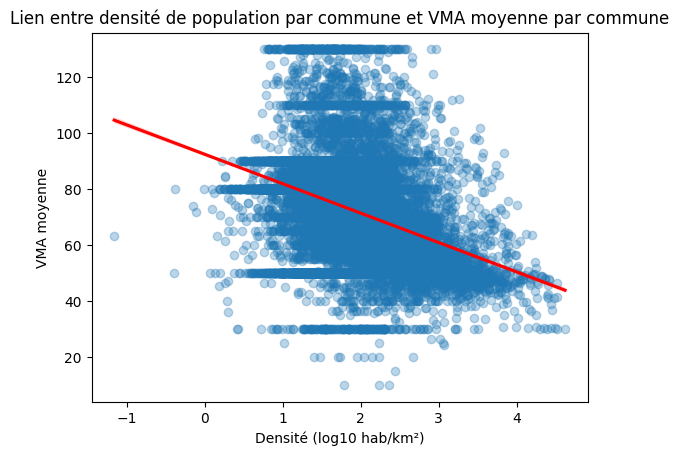

In [706]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_plot_densite['log_densite'] = np.log10(df_plot_densite['densite'])

sns.regplot(data=df_plot_densite, x='log_densite', y='vma_moy_com', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title("Lien entre densité de population par commune et VMA moyenne par commune")
plt.xlabel("Densité (log10 hab/km²)")
plt.ylabel("VMA moyenne")
plt.show()

La corrélation est très claire. Maintenant, observons le lien entre VMA moyenne par commune et gravité moyenne des accidents par commune.

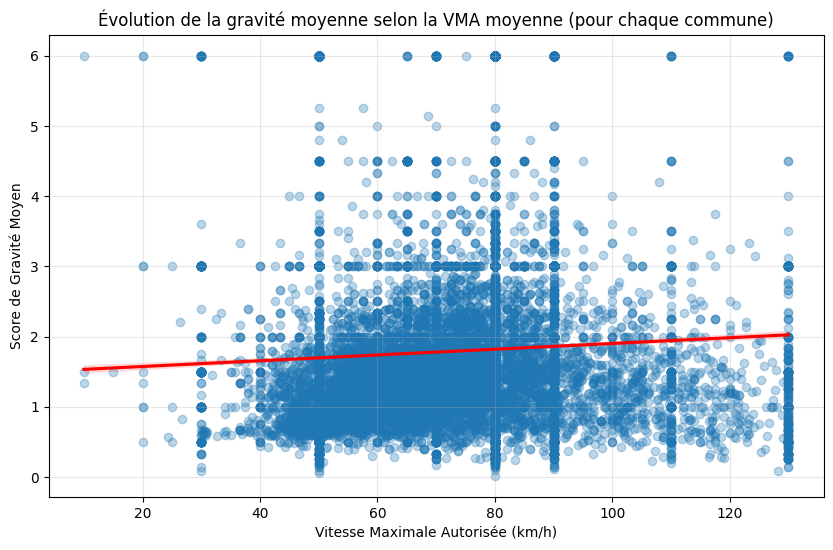

In [707]:
plt.figure(figsize=(10, 6))

sns.regplot(data=df_plot_densite, x='vma_moy_com', y='score_moyen_com', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title("Évolution de la gravité moyenne selon la VMA moyenne (pour chaque commune)")
plt.xlabel("Vitesse Maximale Autorisée (km/h)")
plt.ylabel("Score de Gravité Moyen")
plt.grid(True, alpha=0.3)
plt.show()

Comme attendu, la corrélation est positive. Observons la significativité de la relation.

In [708]:
import statsmodels.api as sm
X = df_plot_densite['vma_moy_com']
y = df_plot_densite['score_moyen_com']

X = sm.add_constant(X) # Ajout de la constante, qui n'est pas présente par défaut dans les régressions linéaires de statsmodels

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        score_moyen_com   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     80.67
Date:              lun., 22 déc. 2025   Prob (F-statistic):           2.91e-19
Time:                        21:58:46   Log-Likelihood:                -29030.
No. Observations:               19007   AIC:                         5.806e+04
Df Residuals:                   19005   BIC:                         5.808e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           1.4921      0.034     43.501      

La corrélation est extrêmement significative étant donné la p-valeur. Par contre le $R^2$ est très faible. La VMA n'explique qu'une partie infime de la variation de gravité moyenne des accidents entre les communes.

Pour la suite de nos analyses, nous ajoutons la métrique de densité de population (hab/km carré) dans notre dataset.

In [709]:
df_communes["Code INSEE"] = df_communes["Code INSEE"].astype(str).str.zfill(5)
df_final2224["Code INSEE"] = df_final2224["Code INSEE"].astype(str).str.zfill(5)

In [710]:
df_final2224 = df_final2224.merge(df_communes[["densite","Code INSEE"]],on="Code INSEE",how="left")

In [723]:
(df_final2224["Code INSEE"]=='98817').sum()

np.int64(107)

In [712]:
df_final2224

,Num_Acc,year,id_usager,id_vehicule,num_veh,place,catu,sexe,trajet,secu1,...,Code INSEE,agg,int,atm,col,lat,long,grav_weight,grav_score,densite
0,202200000001,2022,1 099 700,813 952,A01,1.0,1,1.0,5,2,...,26198,2,3.0,1.0,3.0,"44,5594200000","4,7257200000",3,3,765.086207
1,202200000001,2022,1 099 701,813 953,B01,1.0,1,1.0,5,1,...,26198,2,3.0,1.0,3.0,"44,5594200000","4,7257200000",0,3,765.086207
2,202200000002,2022,1 099 698,813 950,B01,1.0,1,1.0,9,1,...,25204,2,3.0,1.0,3.0,"46,9258100000","6,3462000000",1,1,280.269058
3,202200000002,2022,1 099 699,813 951,A01,1.0,1,1.0,4,1,...,25204,2,3.0,1.0,3.0,"46,9258100000","6,3462000000",0,1,280.269058
4,202200000003,2022,1 099 696,813 948,A01,1.0,1,1.0,0,1,...,22360,2,6.0,1.0,2.0,"48,4931620000","-2,7604390000",0,1,539.792388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377264,202400054401,2024,203 859 570,155 686 119,Y01,1.0,1,2.0,0,0,...,92012,2,1.0,1.0,3.0,"48,83286197","2,24394009",1,1,18390.243902
377265,202400054401,2024,203 859 572,155 686 120,A01,1.0,1,1.0,0,2,...,92012,2,1.0,1.0,3.0,"48,83286197","2,24394009",0,1,18390.243902
377266,202400054402,2024,203 859 569,155 686 118,A01,1.0,1,1.0,4,1,...,94028,2,1.0,1.0,4.0,"48,78330000","2,46660000",1,2,7814.685315
377267,202400054402,2024,203 859 571,155 686 121,B01,1.0,1,2.0,9,1,...,94028,2,1.0,1.0,4.0,"48,78330000","2,46660000",1,2,7814.685315


### Feature Engineering

In [713]:
df_cleaned2224 = df_final2224.copy()

Nous supprimons d'abord les colonnes de jointure. On conserve Num_Acc le temps du nettoyage.

In [714]:
df_cleaned2224=df_cleaned2224.drop(columns=["id_usager","id_vehicule","num_veh"],errors='ignore')

Nous extrayons l'heure seulement de la colonne hrmn (heures et minutes). Les minutes risquent en effet d'apporter plus de bruit que de signal.

In [715]:
if "hrmn" in df_cleaned2224.columns:
    print(df_cleaned2224["hrmn"].isna().sum(),(df_cleaned2224["hrmn"].str.len()<5).sum())
    df_cleaned2224["hr"]=df_cleaned2224["hrmn"].str[:2].astype(int)
df_cleaned2224=df_cleaned2224.drop(columns="hrmn",errors="ignore")

0 0


On extrait également les périodes de la journée, dont le signal peut être encore plus fort.

In [716]:
df_cleaned2224["time_period"] = pd.cut(df_cleaned2224['hr'], 
                               bins=[-1, 6, 11, 14, 18, 24], 
                               labels=['Nuit', 'Matin', 'Midi', 'Apres-midi', 'Soir'])

On consolide les variables de sécurité en ajoutant des variables spécifiques pour le casque, la ceinture, et l'airbag, des variables qui ont des chances d'être corrélées très négativement à la gravité des blessures.

In [717]:
df_cleaned2224["secu3"].value_counts()

secu3
8    362133
0     11525
9      2918
1       270
6       225
4        85
5        55
2        34
7        13
3        11
Name: count, dtype: int64

In [718]:
secu_cols = ['secu1', 'secu2', 'secu3']
df_cleaned2224['ceinture'] = df_cleaned2224[secu_cols].isin([1]).any(axis=1).astype(int)
df_cleaned2224['casque'] = df_cleaned2224[secu_cols].isin([2]).any(axis=1).astype(int)
# Airbag (code 5) ou Gants + Airbag (code 7)
df_cleaned2224['airbag'] = df_cleaned2224[secu_cols].isin([5, 7]).any(axis=1).astype(int)

Vérifions empiriquement nos intuitions.

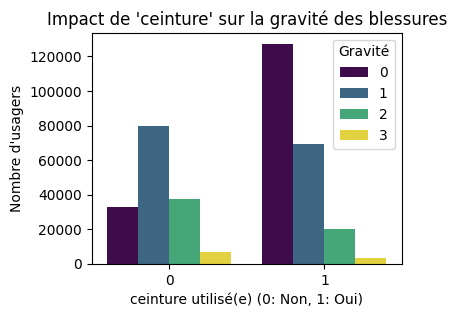

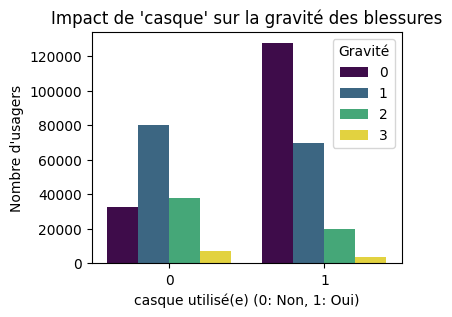

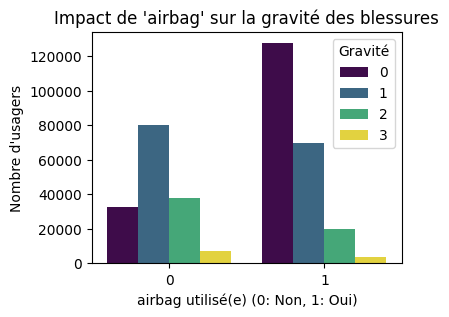

In [719]:
for col in ["ceinture","casque","airbag"]:
    plt.figure(figsize=(4, 3))
    sns.countplot(data=df_cleaned2224, x='ceinture', hue='grav_ord', palette='viridis')
    plt.title(f"Impact de '{col}' sur la gravité des blessures")
    plt.xlabel(f"{col} utilisé(e) (0: Non, 1: Oui)")
    plt.ylabel("Nombre d'usagers")
    plt.legend(title="Gravité")
    plt.show()


Nos intuitions sont donc bonnes.

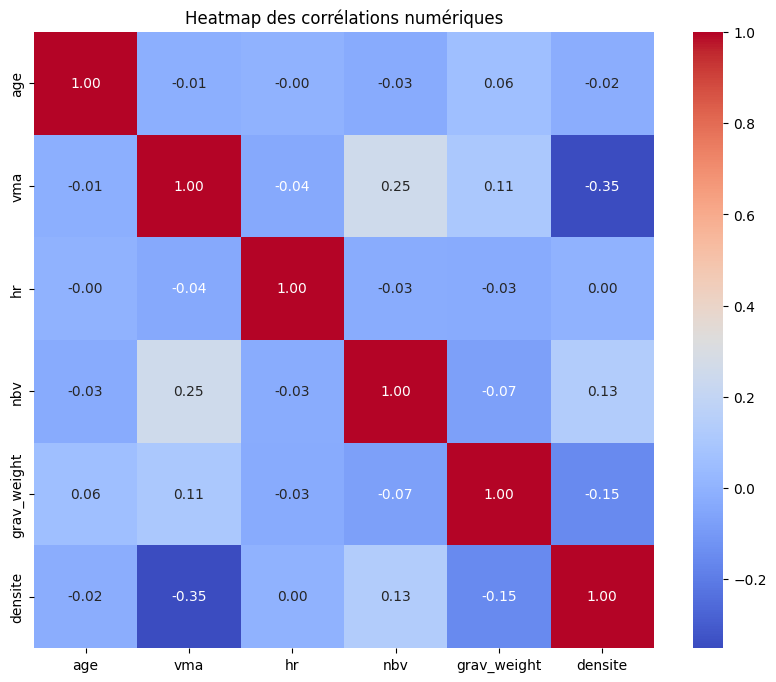

In [720]:
cols_corr = ['age', 'vma', 'hr', 'nbv', 'grav_weight', 'densite']
plt.figure(figsize=(10, 8))
sns.heatmap(df_cleaned2224[cols_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap des corrélations numériques")
plt.show()

In [721]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_final2224[['grav_ord', 'vma', 'age_victime', 'commune_risk_index', 'vma_sq']].corr(), 
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Corrélations avec la Gravité")
plt.show()

# Boxplot pour voir l'impact de la vitesse par type de route
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_final2224, x='catr', y='vma', hue='grav_ord')
plt.title("Distribution de la VMA par Catégorie de route et Gravité")
plt.show()

KeyError: "['age_victime', 'commune_risk_index', 'vma_sq'] not in index"

<Figure size 1200x1000 with 0 Axes>

## Dataframe 2005-2021

On supprime la colonne redondante d'index "Unnamed: 0" (liée au format d'importation) et on renomme les colonnes "num_acc" et "annee" pour être en cohérence avec le dataset df_final2224 :

In [ ]:
url_05_21 = {
    "carac" : "https://www.data.gouv.fr/api/1/datasets/r/a3cac8bc-4a07-4124-8a08-633a3a91d40b",
    "lieux" : "https://www.data.gouv.fr/api/1/datasets/r/b7f25e45-de32-4801-b0eb-62989f1a7406",
    "usagers" : "https://www.data.gouv.fr/api/1/datasets/r/a64b1b9f-4d56-4b26-ae90-9f40b878e109"
}

In [ ]:
df_old={}
for type,link in url_05_21.items():
    df_old[type] = pd.read_csv(link,
                               encoding="latin-1",  # Old files, with a different encoding than the recent ones
                               sep=",")
df_old

# Prend environ 3 min à tourner

KeyboardInterrupt: 

In [ ]:
print(df_old["carac"].columns,"\n",carac_new.columns)

Index(['Unnamed: 0', 'num_acc', 'mois', 'jour', 'hrmn', 'lum', 'agg', 'int',
       'atm', 'col', 'com', 'adr', 'gps', 'lat', 'long', 'dep', 'annee'],
      dtype='object') 
 Index(['Num_Acc', 'year', 'jour', 'mois', 'hrmn', 'lum', 'dep', 'com', 'agg',
       'int', 'atm', 'col', 'adr', 'lat', 'long'],
      dtype='object')


In [ ]:
print(df_old["usagers"].columns,"\n",usagers_new.columns)

Index(['Unnamed: 0', 'num_acc', 'place', 'catu', 'grav', 'sexe', 'trajet',
       'secu', 'locp', 'actp', 'etatp', 'an_nais', 'num_veh', 'annee',
       'id_vehicule', 'secu1', 'secu2', 'secu3'],
      dtype='object') 
 Index(['Num_Acc', 'year', 'id_usager', 'id_vehicule', 'num_veh', 'place',
       'catu', 'grav', 'sexe', 'an_nais', 'trajet', 'secu1', 'secu2', 'secu3',
       'locp', 'actp', 'etatp'],
      dtype='object')


In [ ]:
for type in ["usagers","carac","lieux"]:
    df_old[type]=df_old[type].rename(columns={"annee":"year","num_acc":"Num_Acc"})
    if "Unnamed: 0" in df_old[type].columns:
        df_old[type].drop(columns="Unnamed: 0",inplace=True)

Comme pour les données récentes, on supprime plusieurs colonnes de "lieux" :

In [ ]:
df_old["lieux"]=df_old["lieux"].drop(columns=["voie","v1","v2","pr","pr1"])
df_old["lieux"].head(20)

,Num_Acc,catr,circ,nbv,vosp,prof,plan,lartpc,larrout,surf,infra,situ,env1,year,vma
0,200500000001,3.0,2.0,2.0,0.0,1.0,1.0,0.0,63.0,1.0,0.0,1.0,0.0,2005,NaN
1,200500000002,2.0,0.0,2.0,1.0,1.0,1.0,0.0,100.0,1.0,0.0,5.0,0.0,2005,NaN
2,200500000003,2.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,2.0,0.0,5.0,0.0,2005,NaN
3,200500000004,3.0,2.0,2.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,2005,NaN
4,200500000005,3.0,2.0,2.0,0.0,1.0,3.0,0.0,59.0,2.0,0.0,3.0,0.0,2005,NaN
5,200500000006,3.0,2.0,2.0,0.0,1.0,3.0,0.0,70.0,2.0,0.0,5.0,0.0,2005,NaN
6,200500000007,3.0,2.0,0.0,0.0,1.0,1.0,0.0,78.0,1.0,0.0,1.0,0.0,2005,NaN
7,200500000008,3.0,2.0,2.0,0.0,1.0,3.0,0.0,69.0,1.0,0.0,3.0,0.0,2005,NaN
8,200500000009,3.0,2.0,2.0,0.0,0.0,1.0,0.0,67.0,1.0,0.0,1.0,0.0,2005,NaN
9,200500000010,2.0,0.0,2.0,0.0,1.0,1.0,0.0,70.0,2.0,0.0,1.0,0.0,2005,NaN


Ici aussi, nous avons bien un seul enregistrement des caractéristiques pour chaque identifiant d'accident. Mais c'est aussi le cas pour les enregistrements de lieux. Par contre, nous avons moins d'enregistrements pour "lieux" que pour "carac", ce qui signifie qu'il manque des données sur le lieu de certains accidents.

In [ ]:
print((df_old["carac"]["Num_Acc"].value_counts()!=1).sum())
print((df_old["lieux"]["Num_Acc"].value_counts()!=1).sum())

0
0


On voit que pour tous les accidents dans df_old["lieux"] nous avons un enregistrement dans df_old["carac"] :

In [ ]:
(~df_old["lieux"]["Num_Acc"].isin(df_old["carac"]["Num_Acc"])).sum()

np.int64(0)

Observons s'il existe des années pour lesquelles on n'a pas d'enregistrement "lieux".

In [ ]:
print(set(df_old["carac"]["year"].unique())-set(df_old["lieux"]["year"].unique()))

{np.int64(2020), np.int64(2021)}


Pour chaque année, combien a-t-on d'accidents dans "carac" sans enregistrement dans "lieux" ?

In [ ]:
for y in df_old["carac"]["year"].unique():
    s=0
    s+=(~df_old["carac"][df_old["carac"]["year"]==y]["Num_Acc"].isin(df_old["lieux"]["Num_Acc"])).sum()
    print(s,y)

0 2005
0 2006
0 2007
0 2008
0 2009
0 2010
0 2011
0 2012
0 2013
0 2014
0 2015
0 2016
0 2017
0 2018
0 2019
47744 2020
56518 2021


2020 et 2021 sont les seules années pour lesquelles on n'a pas d'enregistrement de "lieux".

In [ ]:
for name in names:
    df_old[name].to_csv(f"data_interm/old/{name}_old.csv",index=False)

### Charger csv

In [ ]:
carac_old = pd.read_csv("data_interm/old/carac_old.csv")
usagers_old = pd.read_csv("data_interm/old/usagers_old.csv")
lieux_old = pd.read_csv("data_interm/old/lieux_old.csv")

C:\Users\berna\AppData\Local\Temp\ipykernel_37632\3289329442.py:1: DtypeWarning: Columns (3,9,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  carac_old = pd.read_csv("data_interm/old/carac_old.csv")
C:\Users\berna\AppData\Local\Temp\ipykernel_37632\3289329442.py:2: DtypeWarning: Columns (8,13) have mixed types. Specify dtype option on import or set low_memory=False.
  usagers_old = pd.read_csv("data_interm/old/usagers_old.csv")


In [ ]:
KEY = ["Num_Acc","year"]
df_full_old = usagers_old.merge(carac_old,on=KEY,how="left").merge(lieux_old,on=KEY,how="left")

On télécharge en parquet pour faciliter l'exploration de données. On remarque que ACTP, qui correspond à l'action du piéton selon la typologie suivante : 
>Se déplaçant 
>* 0 - non renseigné ou sans objet 
>* 1 - Sens véhicule heurtant 
>* 2 - Sens inverse du véhicule 

>Divers  
>* 3 - Traversant 
>* 4 - Masqué 
>* 5 - Jouant – courant 
>* 6 - Avec animal 
>* 9 - Autre

contient des valeurs qui ne sont PAS numériques.

En effet, à partir de 2019, on a également -1 : non renseigné, A : Monte/Descend du véhicule, et B : inconnue.

In [ ]:
# df_full_old.to_parquet("df_full_old.parquet")

In [ ]:
print(carac_old[["long","lat"]].isna().sum(),len(carac_old))
# Nous avons beaucoup de données manquantes sur la longitude et la latitude pour 2005-2021.

long    487072
lat     487068
dtype: int64 1121571


In [ ]:
(~lieux_old["vma"].isnull()).sum()

np.int64(58840)

Notons que la colonne vma a été ajoutée après 2019. C'est une feature très importante pour la gravité.

<Axes: xlabel='grav', ylabel='Count'>

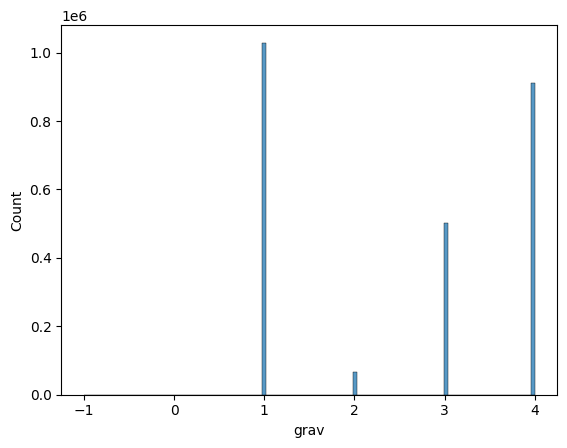

In [ ]:
sns.histplot(usagers_old["grav"])

<Axes: xlabel='grav', ylabel='Count'>

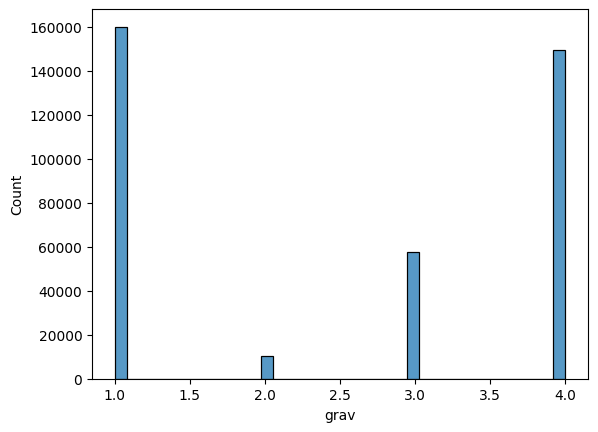

In [ ]:
sns.histplot(usagers_new["grav"])

<Axes: xlabel='grav', ylabel='Count'>

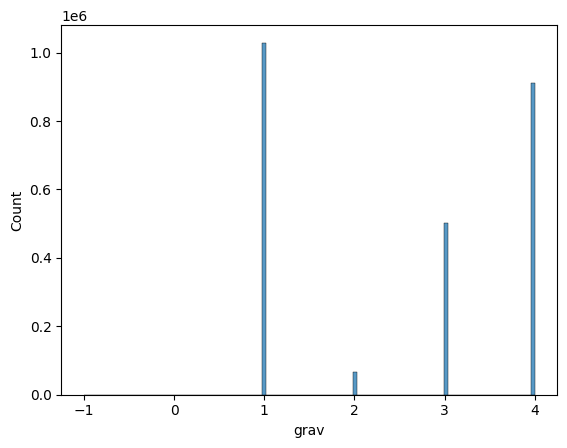

In [ ]:
dict1 = {
    -1:"NA",
    1:"Indemne",
    2:"Tué",
    3:"Blessé", # Blessé hospitalisé -> Blessé
    4:"Blessé", # Blessé léger -> Blessé
}

dict2 = {
    "NA":-1,
    "Indemne":0,
    "Blessé":1,
    "Tué":2,
    }

df_full_old["gravité"]=df_full_old["grav"].apply(lambda x:dict1[x])
df_full_old["grav_merged"]=df_full_old["gravité"].apply(lambda x:dict2[x])
sns.histplot(df_full_old["grav"])

In [ ]:
print((df_full_old["grav"]==-1).sum())
print(len(df_full_old))

60
2509620


In [ ]:
df_full_old=df_full_old[df_full_old["grav"]!=-1]

## Fusion des anciennes données et des nouvelles données

Steps suivants : 

Observons les différences dans les noms de colonnes du format des anciens datasets (2005-2021), et des nouveaux datasets (2022-2024).

In [ ]:
cols_recentes = set(df_final2224.columns)
cols_anciennes = set(df_full_old.columns)

unique_recent = cols_recentes-cols_anciennes # Soustraire les sets permet de ne garder que les colonnes uniquement présentes en 2022-2024
unique_ancien = cols_anciennes-cols_recentes # Colonnes uniquement présentes en 2005-2021

print(unique_ancien,unique_recent)

print(cols_anciennes,cols_recentes)

{'grav_merged', 'lartpc', 'secu', 'gravité', 'gps', 'env1'} {'', 'grav_weight', 'grav_ord', 'nb_param_lieux', 'id_usager', 'age'}
{'jour', 'com', 'prof', 'secu', 'secu3', 'catu', 'secu2', 'locp', 'atm', 'nbv', 'secu1', 'vosp', 'env1', 'int', 'col', 'larrout', 'grav', 'year', 'dep', 'adr', 'long', 'surf', 'gps', 'etatp', 'catr', 'trajet', 'lum', 'hrmn', 'plan', 'lartpc', 'place', 'an_nais', 'sexe', 'mois', 'circ', 'agg', 'grav_merged', 'id_vehicule', 'infra', 'situ', 'lat', 'gravité', 'vma', 'num_veh', 'actp', 'Num_Acc'} {'', 'jour', 'grav_ord', 'com', 'prof', 'secu3', 'catu', 'secu2', 'locp', 'nbv', 'vosp', 'secu1', 'atm', 'int', 'nb_param_lieux', 'col', 'larrout', 'grav', 'year', 'dep', 'adr', 'long', 'surf', 'id_usager', 'etatp', 'catr', 'trajet', 'lum', 'hrmn', 'plan', 'place', 'an_nais', 'sexe', 'mois', 'grav_weight', 'circ', 'agg', 'id_vehicule', 'infra', 'situ', 'lat', 'vma', 'num_veh', 'actp', 'Num_Acc', 'age'}


Comme on dispose déjà de donnée sur l'adresse de l'accident, et en particulier sur sa longitude et sa latitude, l'ancienne colonne GPS (qui ne prend qu'une seule mystérieuse valeur, "M") n'est pas utile. Nous pouvons la supprimer.
De même, la colonne id_usager n'est pas très intéressante. Elle peut apparaître plusieurs fois (si un individu fait plusieurs accidents dans l'année), mais nous pouvons déjà différencier les individus au sein d'un même numéro d'accident. Chaque accidenté de chaque accident est déjà indexé par l'index du dataframe.
Nous pouvons donc supprimer ces deux colonnes.

"env1" correspond à la proximité d'une école. Cette donnée n'est plus collectée et ne pourra pas être utilisée pour prédire la gravité d'un accident. Nous pouvons la supprimer.

Enfin, la colonne "secu" correspond de 2005 à 2021 à un code sur deux caractères : 

Le premier concerne l'existence d'un équipement de sécurité:
    
    1 – Ceinture,
    2 – Casque,
    3 – Dispositif enfants,
    4 – Equipement réfléchissant,
    9 – Autre

Le second concerne l'utilisation de cet équipement de sécurité :
    
    1 – Oui,
    2 – Non,
    3 – Non déterminable

Dans les versions plus récentes, il est question de l'existence ET de l'utilisation d'un équipement de sécurité, jusqu'à trois à la fois (secu1,secu2,secu3):
    
    -1 – Non renseigné  
    0 – Aucun équipement  
    1 – Ceinture  
    2 – Casque  
    3 – Dispositif enfants  
    4 – Gilet réfléchissant  
    5 – Airbag (2RM/3RM)  
    6 – Gants (2RM/3RM)  
    7 – Gants + Airbag (2RM/3RM)  
    8 – Non déterminable  
    9 – Autre

Cette nouvelle nomenclature (secu1,secu2,secu3) qui permet une analyse plus granulaire a été introduite en 2019, avec id_vehicule (identifiant du véhicule, que nous pouvons également abandonner).

Dans les étapes suivantes, nous pouvons donc abandonner "gps", "id_vehicule", "id_usager", et réfléchir à une modification de la colonne "secu" pour harmoniser les données 05-21 avec 22-24.


In [ ]:
df_final2224.drop(columns=["id_usager"],inplace=True,errors="ignore")
df_full_old.drop(columns=[["gps","env1"]],inplace=True,errors="ignore")
df_full_old["nb_param_lieux"]=1

Notre code harmonise les deux époques en extrayant deux indicateurs binaires fondamentaux : ceinture et casque.

In [ ]:
from modules.process import process_df
df_final_old = df_full_old.copy()

process_df.clean_secu(df_final_old)

# Vérification rapide
print("Répartition Ceinture (Avant 2019) :")
print(df_final_old['secu_ceinture'].value_counts())

print("\nRépartition Casque (Avant 2019) :")
print(df_final_old['secu_casque'].value_counts())

Répartition Ceinture (Avant 2019) :
secu_ceinture
0    2509560
Name: count, dtype: int64

Répartition Casque (Avant 2019) :
secu_casque
0    2509560
Name: count, dtype: int64


In [ ]:
df_full_old

,Num_Acc,place,catu,grav,sexe,trajet,secu,locp,actp,etatp,...,lartpc,larrout,surf,infra,situ,env1,vma,gravité,grav_merged,nb_param_lieux
0,2.005000e+11,1.0,1,4,1,1.0,11.0,0.0,0,0.0,...,0.0,63.0,1.0,0.0,1.0,0.0,NaN,Blessé,1,1
1,2.005000e+11,1.0,1,3,2,3.0,11.0,0.0,0,0.0,...,0.0,63.0,1.0,0.0,1.0,0.0,NaN,Blessé,1,1
2,2.005000e+11,2.0,2,1,1,0.0,11.0,0.0,0,0.0,...,0.0,63.0,1.0,0.0,1.0,0.0,NaN,Indemne,0,1
3,2.005000e+11,4.0,2,1,1,0.0,31.0,0.0,0,0.0,...,0.0,63.0,1.0,0.0,1.0,0.0,NaN,Indemne,0,1
4,2.005000e+11,5.0,2,1,1,0.0,11.0,0.0,0,0.0,...,0.0,63.0,1.0,0.0,1.0,0.0,NaN,Indemne,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2509615,2.021001e+11,1.0,1,4,1,0.0,NaN,0.0,0,-1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Blessé,1,1
2509616,2.021001e+11,1.0,1,4,1,5.0,NaN,0.0,0,-1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Blessé,1,1
2509617,2.021001e+11,1.0,1,3,1,0.0,NaN,0.0,0,-1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Blessé,1,1
2509618,2.021001e+11,1.0,1,3,1,3.0,NaN,-1.0,-1,-1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Blessé,1,1


In [ ]:
df_final_old["secu_ceinture"].sum()

np.int64(0)

<Axes: xlabel='secu', ylabel='count'>

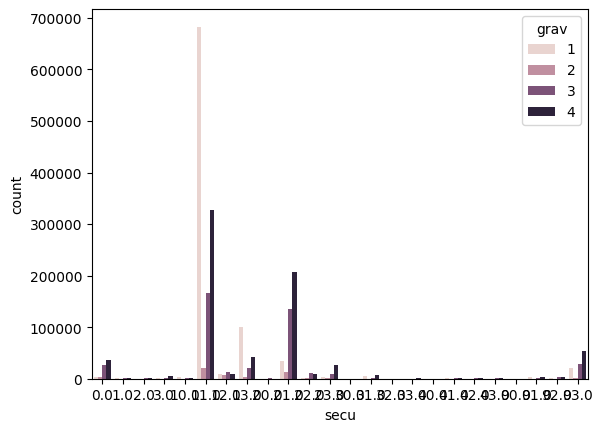

In [ ]:
sns.countplot(data=df_full_old,x="secu",hue="grav")

In [ ]:
df_full_old.drop(columns=["secu"],inplace=True,errors="ignore")

In [ ]:
sns.countplot(data=df_full_old,x="secu_ceinture",hue="grav")

ValueError: Could not interpret value `secu_ceinture` for `x`. An entry with this name does not appear in `data`.

La définition de "Blessé hospitalisé" a changé depuis 2018, ce qui rend la comparaison exacte impossible entre 2005-2018 et 2019-2024. Pour internaliser le bruit, nous fusionnons les valeurs "Blessé hospitalisé" et "Blessé léger" pour avoir une variable plus générale "Blessé".

In [ ]:
dict1 = {
    -1:"NA",
    1:"Indemne",
    2:"Tué",
    3:"Blessé", # Blessé hospitalisé -> Blessé
    4:"Blessé", # Blessé léger -> Blessé
}

dict2 = {
    "NA":-1,
    "Indemne":0,
    "Blessé":1,
    "Tué":2,
    }
usagers_new["gravité"]=usagers_new["grav"].apply(lambda x:dict1[x])
usagers_new["grav"]=usagers_new["gravité"].apply(lambda x :dict2[x])